# AI Programming Final Project
### <span style='color:purple'> Name: Dana Nidal  </span>


# First we import all the  libraries we need in our work

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read our Dataset

In [ ]:
data = pd.read_excel(r"C:\Users\Lenovo\Downloads\Book1.xlsx")
data.head()

,Province,Confirmed,Recovered,Deaths
0,DKI Jakarta,3032,234,287
1,Jawa Barat,696,45,59
2,Jawa Timur,590,98,54
3,Sulawesi Selatan,370,43,25
4,Jawa Tengah,349,51,44


# use describe to compute and display summary statistics in our DataFrame

In [ ]:
data.describe()

,Confirmed,Recovered,Deaths
count,34.000000,34.000000,34.000000
mean,192.617647,20.176471,17.117647
std,528.469546,42.856682,50.128782
min,1.000000,0.000000,0.000000
25%,10.250000,2.000000,1.000000
50%,52.500000,6.000000,3.000000
75%,94.250000,12.750000,7.000000
max,3032.000000,234.000000,287.000000


# now we  filter the Province column(label) from the other columns (features)

In [ ]:
label = data.filter(["Province"], axis=1)
features = data.drop(["Province"], axis=1)
features.head()

,Confirmed,Recovered,Deaths
0,3032,234,287
1,696,45,59
2,590,98,54
3,370,43,25
4,349,51,44


# Bar plot to show Number of COVID-19 cases each Province in Indonesia

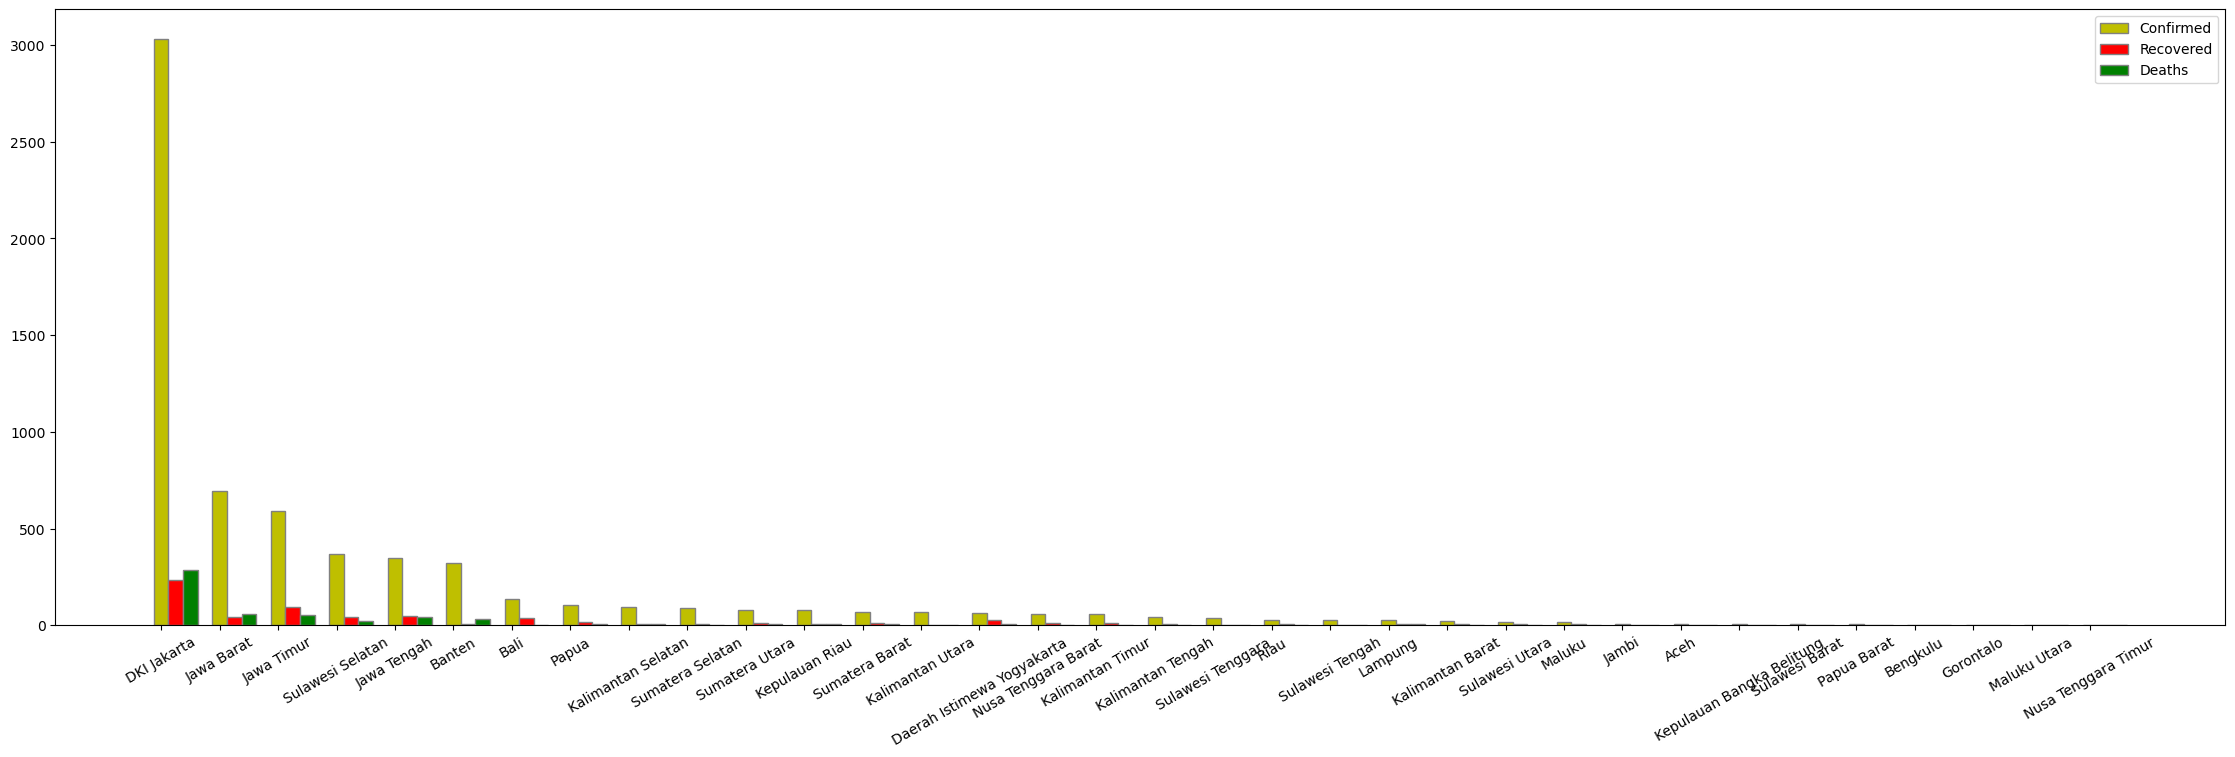

In [ ]:
# set width of bar
barWidth = 0.25
fig = plt.subplots(figsize =(28, 8))

# Set position of bar on X axis
br1 = np.arange(len(data['Confirmed']))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]

# Make the plot
plt.bar(br1, data['Confirmed'], color ='y', width = barWidth, edgecolor ='grey', label ='Confirmed')
plt.bar(br2, data['Recovered'], color ='r', width = barWidth, edgecolor ='grey', label ='Recovered')
plt.bar(br3, data['Deaths'], color ='g', width = barWidth, edgecolor ='grey', label ='Deaths')

# Adding Xticks
plt.xticks(range(len(data['Province'])),data['Province'], rotation=30)

plt.legend()
plt.show()

# importing standerd scaler from sklearn to fit and transform features

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
features = sc.fit_transform(features)

# we used Elbow method to find the optimal number of clusters

C:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


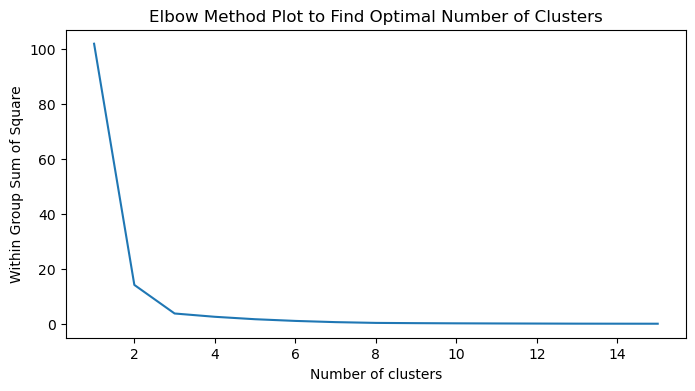

In [ ]:
#Elbow method
loss = []
for i in range(1,16):
    km = KMeans(n_clusters = i).fit(features)
    loss.append(km.inertia_)
plt.figure(figsize=(8,4))
plt.plot(range(1,16),loss)
plt.title('Elbow Method Plot to Find Optimal Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within Group Sum of Square')
plt.show()

# Silhouette method its another way to find the optimal number of clusters

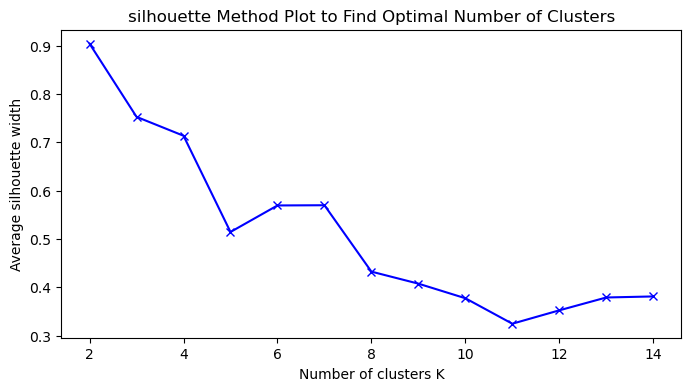

In [ ]:
# Silhouette Method
sil = []
# Number of clusters in range 2-15
K = range(2, 15)
for n in K:
    algorithm = (KMeans(n_clusters = n))
    algorithm.fit(features)
    labels = algorithm.labels_
    sil.append(silhouette_score(features, labels, metric = 'euclidean'))
plt.figure(figsize=(8,4))
plt.plot(K,sil,'bx-')
plt.title('silhouette Method Plot to Find Optimal Number of Clusters')
plt.xlabel('Number of clusters K')
plt.ylabel('Average silhouette width')
plt.show()

# Gap Statistics is used for the same reason as Elbow&Silhouette Methods

C:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Wi

Optimal k is:  10


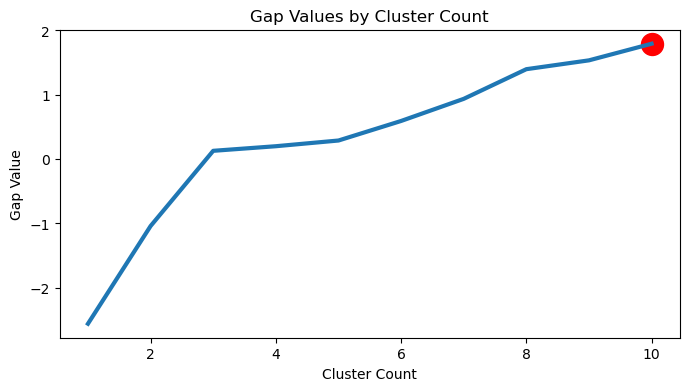

In [ ]:
# gap statistic
def optimalK(data, nrefs=3, maxClusters=15):
    gaps = np.zeros((len(range(1, maxClusters)),))
    resultsdf = pd.DataFrame({'clusterCount':[], 'gap':[]})
    for gap_index, k in enumerate(range(1, maxClusters)):
        # Holder for reference dispersion results
        refDisps = np.zeros(nrefs)
        # For n references, generate random sample and perform kmeans getting resulting dispersion of each loop
        for i in range(nrefs):
            # Create new random reference set
            randomReference = np.random.random_sample(size=data.shape)
            # Fit to it
            km = KMeans(k)
            km.fit(randomReference)

            refDisp = km.inertia_
            refDisps[i] = refDisp
        # Fit cluster to original data and create dispersion
        km = KMeans(k)
        km.fit(features)

        origDisp = km.inertia_
        # Calculate gap statistic
        gap = np.log(np.mean(refDisps)) - np.log(origDisp)
        # Assign this loop's gap statistic to gaps
        gaps[gap_index] = gap

        resultsdf = resultsdf.append({'clusterCount':k, 'gap':gap}, ignore_index=True)
    return (gaps.argmax() + 1, resultsdf)  # Plus 1 because index of 0 means 1 cluster is optimal, index 2 = 3 clusters are optimal

    # Automatically output the number of clusters
k, gapdf = optimalK(features, nrefs=3, maxClusters=11)
print('Optimal k is: ', k)
# Visualization
plt.figure(figsize=(8,4))
plt.plot(gapdf.clusterCount, gapdf.gap, linewidth=3)
plt.scatter(gapdf[gapdf.clusterCount == k].clusterCount, gapdf[gapdf.clusterCount == k].gap, s=250, c='r')
plt.xlabel('Cluster Count')
plt.ylabel('Gap Value')
plt.title('Gap Values by Cluster Count')
plt.show()

### From the previous plots we can see that in the Elbow & Silhouette methods the optimal number of Clusters k=2 which is the same in the paper in the other way the Gap statistics shows that the optimal number of clusters k=10 which is completly different from the clusters number  k in the paper

# Now we use the Kmeans Algorithm

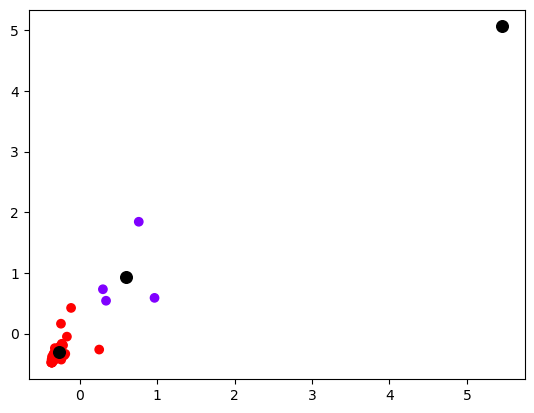

In [ ]:
km_model = KMeans(n_clusters=3)
km_model.fit(features)
#print the data points with prediced labels
plt.scatter(features[:,0], features[:,1], c= km_model.labels_, cmap='rainbow' )
#print the predicted centroids
plt.scatter(km_model.cluster_centers_[:, 0], km_model.cluster_centers_[:, 1], s=70, c='black')

In [ ]:
m = km_model.labels_
pd.DataFrame(m,label, columns=['clusters'])

,clusters
"(DKI Jakarta,)",1
"(Jawa Barat,)",0
"(Jawa Timur,)",0
"(Sulawesi Selatan,)",0
"(Jawa Tengah,)",0
"(Banten,)",2
"(Bali,)",2
"(Papua,)",2
"(Kalimantan Selatan,)",2
"(Sumatera Selatan,)",2


## Here we have finished building our model and obtained our results. The results that appeared are very similar to the results in the paper, with a slight difference in the numbers of the clusters, where in the paper their numbers were 1, 2, and 3, but in my model , the numbers were 0, 1, and 2,,The other difference is the inclusion of the province Banten in the  cluster 2 , although it is in cluster number 1 in the paper,the rest of the results are pretty much the same.